In [251]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import uniform, uniform, loguniform, randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

import xgboost as xgb


In [237]:
# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code', 'Default Flag', 'Major Stress', "Monthly Reporting Period",
                        'Distress Date', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number',
                         'Estimated Loan-to-Value (ELTV)']


# Load in all files from TrainingData Folder
for year in range(2000, 2018+1):
    year_path = os.path.join(root_dir, f"Year{year}")
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                df = df[(df["Default Flag"] == 1) & (~df["Actual Loss Calculation"].isna()) & (~(df["Actual Loss Calculation"] == 0))]
                TRAIN_list.append(df) 
                #LABELS_list.append(df['Default Flag'])               
                


TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)

In [238]:
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)

In [245]:
TRAIN["Est. Home Val at Origination"] = TRAIN["Original UPB"] / (TRAIN["Original Combined Loan-to-Value (CLTV)"] / 100)
TRAIN["Est. Current Home Val"] = TRAIN["Est. Home Val at Origination"] * (TRAIN["HPI Change %"] + 1)

TRAIN["Geographic ELTV"] = TRAIN["Current Actual UPB"] / TRAIN["Est. Current Home Val"]

def estimate_months_remaining(row):
    L = row['Original UPB']
    B = row['Current Actual UPB']
    annual_rate = row["Original Interest Rate"]
    N_orig = row['Original Loan Term']
    
    r = annual_rate / 100 / 12

    if r == 0:
        P = L / N_orig
    else:
        P = (L * r) / (1 - (1 + r) ** -N_orig)

    if P <= r * B:
        return np.nan  # Loan isn't amortizing

    N_remaining = (np.log(P) - np.log(P - r * B)) / np.log(1 + r)
    return round(N_remaining)

TRAIN.loc[TRAIN["Remaining Months to Legal Maturity"].isna(), "Remaining Months to Legal Maturity"] = TRAIN[TRAIN["Remaining Months to Legal Maturity"].isna()].apply(lambda row : estimate_months_remaining(row), axis=1)
TRAIN.loc[TRAIN["Mortgage Insurance Percentage (MI %)"] == 999, "Mortgage Insurance Percentage (MI %)"] = 0

In [242]:
TRAIN["Zero Balance UPB Over Expected"] = TRAIN["Zero Balance Removal UPB"] - TRAIN["Current Actual UPB"]
TRAIN["Net Sales Proceeds Over Expected"] = TRAIN["Net Sales Proceeds"] - TRAIN["Est. Current Home Val"]
TRAIN["MI Cap Payout"] = (TRAIN["Mortgage Insurance Percentage (MI %)"] * TRAIN["Original UPB"] / 100)
TRAIN["Interest and Expenses"] = TRAIN["Delinquent Accrued Interest"] - TRAIN["Expenses"].fillna(0)
TRAIN["Loss Estimate 1"] = TRAIN["Current Actual UPB"] - TRAIN["Est. Current Home Val"]

In [243]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(TRAIN[["Est. Current Home Val"]], TRAIN["Interest and Expenses"])

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

TRAIN["Estimated Interest and Expenses"] = model.predict(TRAIN[["Est. Current Home Val"]])
TRAIN["Estimated MI Recoveries"] = TRAIN["MI Cap Payout"].combine(TRAIN["Current Actual UPB"] - TRAIN["Est. Current Home Val"] + TRAIN["Estimated Interest and Expenses"], min).apply(lambda x : max(0, x))
TRAIN["MI Recoveries Over Expected"] = TRAIN["MI Recoveries"] - TRAIN["Estimated MI Recoveries"]
TRAIN["Loss Estimate 3"] = TRAIN["Current Actual UPB"] - TRAIN["Est. Current Home Val"] - TRAIN["Estimated MI Recoveries"] + TRAIN["Estimated Interest and Expenses"]
TRAIN["Loss Estimate 4"] = TRAIN["Current Actual UPB"] - TRAIN["Est. Current Home Val"] + TRAIN["Estimated Interest and Expenses"]

Slope: 0.14490168125835193
Intercept: 7234.557086138826


In [278]:
RESPONSE_VAR = (-1*TRAIN["Actual Loss Calculation"]).apply(lambda x : max(x, 0))
FEATURES = TRAIN[["Mortgage Insurance Percentage (MI %)", "MI Cap Payout", "Estimated MI Recoveries", "Geographic ELTV",
                  "Original Combined Loan-to-Value (CLTV)", "Est. Current Home Val", "Remaining Months to Legal Maturity", 
                  "HPI Change %", "Current Actual UPB", "Numeric Delinquency"]]

In [279]:
state = 40

X_train, X_val, y_train, y_val = train_test_split(
    FEATURES, RESPONSE_VAR, test_size=0.2, random_state=state
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

Train shape: (14290, 10), Validation shape: (3573, 10)


In [280]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform
import xgboost as xgb

NumParamSearchIterations = 200

param_distributions = {
    'n_estimators': range(15, 75),
    'learning_rate': uniform(0.01, 0.08),
    'max_depth': range(4, 15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
}


# Setup RandomizedSearchCV
hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=state,
        objective='reg:squarederror',
    ),
    scoring='neg_root_mean_squared_error',
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=2,
    n_jobs=6
)

search = hyperparameter_tuning.fit(X_train, y_train,verbose=True)

# Output best results
print("\nBest Hyperparameters:", search.best_params_)
print("Best CV Brier Score (negated):", search.best_score_)

# Extract best model
best_model = search.best_estimator_

y_val_preds = best_model.predict(X_val)

# Final validation metrics
rmse = mean_squared_error(y_val, y_val_preds, squared=False)
mae = mean_absolute_error(y_val, y_val_preds)
r2 = r2_score(y_val, y_val_preds)

print("\nValidation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Fitting 3 folds for each of 200 candidates, totalling 600 fits

Best Hyperparameters: {'colsample_bytree': 0.7337697924282733, 'learning_rate': 0.06553797567091417, 'max_depth': 5, 'n_estimators': 68, 'subsample': 0.7599976069987099}
Best CV Brier Score (negated): -46331.18667639804

Validation Metrics:
RMSE: 45701.8161
MAE: 32266.8795
R2 Score: 0.4433


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [283]:
import pickle

best_model_full = xgb.XGBRegressor(
    **search.best_params_,
    random_state=state,
    objective='reg:squarederror'
)
best_model_full.fit(FEATURES, RESPONSE_VAR)

with open("Models/LGD.pkl", "wb") as f:
    pickle.dump(best_model_full, f)

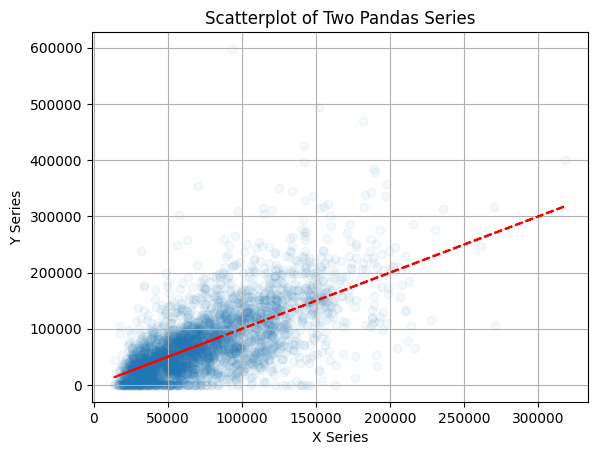

In [282]:
plt.scatter(y_val_preds,y_val, alpha=0.05)
plt.plot(y_val_preds, y_val_preds, color='red', linestyle='--', label='y = x')

plt.xlabel("X Series")
plt.ylabel("Y Series")
plt.title("Scatterplot of Two Pandas Series")
plt.grid(True)
plt.show()


C:\Users\matth\AppData\Local\Temp\ipykernel_36532\497521805.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_mi.groupby('LTV_Bucket')
C:\Users\matth\AppData\Local\Temp\ipykernel_36532\497521805.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mi_proportions = grouped.apply(lambda x: (x['MI Recoveries'] > 0).mean()).reset_index(name='Proportion_with_MI_Payouts')


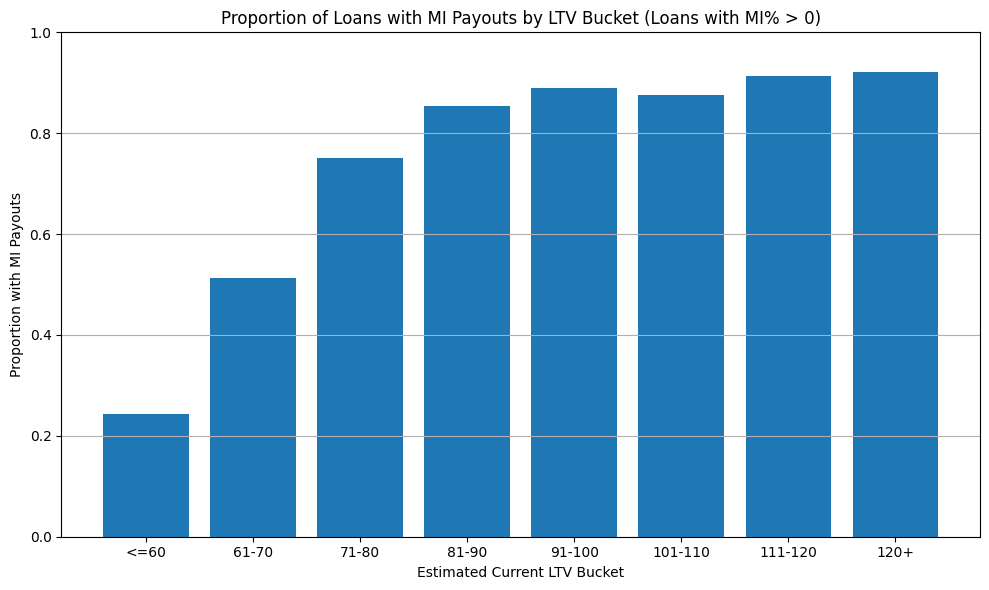

In [ ]:
df_mi = TRAIN[TRAIN['Mortgage Insurance Percentage (MI %)'] > 0].copy()

# Create LTV buckets
bins = [0, 60, 70, 80, 90, 100, 110, 120, np.inf]
labels = ['<=60', '61-70', '71-80', '81-90', '91-100', '101-110', '111-120', '120+']
df_mi['LTV_Bucket'] = pd.cut(df_mi['Geographic Est. ELTV']*100, bins=bins, labels=labels, right=False)

# Calculate the proportion of loans with MI payouts per LTV bucket
grouped = df_mi.groupby('LTV_Bucket')
mi_proportions = grouped.apply(lambda x: (x['MI Recoveries'] > 0).mean()).reset_index(name='Proportion_with_MI_Payouts')

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(mi_proportions['LTV_Bucket'], mi_proportions['Proportion_with_MI_Payouts'])
plt.title('Proportion of Loans with MI Payouts by LTV Bucket (Loans with MI% > 0)')
plt.xlabel('Estimated Current LTV Bucket')
plt.ylabel('Proportion with MI Payouts')
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = TRAIN.corr()

corr_matrix.to_csv("Corr.csv", index=True)

In [ ]:
corr_matrix

,Credit Score,Mortgage Insurance Percentage (MI %),Number of Units,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan-to-Value (LTV),Original Interest Rate,Original Loan Term,Number of Borrowers,...,Est. Current Home Val,Geographic Est. ELTV,Zero Balance UPB Over Expected,Net Sales Proceeds Over Expected,ESTIMATED MI RECOVERIES,MI Recoveries Over Expected,MI Cap Payout,Expected Loss on Sale,Estimated Loss on Sale,True Loss on Sale
Credit Score,1.000000,-0.073271,0.027234,0.053255,0.063416,0.101266,0.019051,-0.221651,0.027825,-0.042334,...,0.024205,0.124656,0.011523,0.048786,-0.044482,0.013124,-0.044483,-0.097119,-0.097119,-0.036168
Mortgage Insurance Percentage (MI %),-0.073271,1.000000,-0.043061,0.369817,-0.045756,-0.053475,0.498418,0.179715,0.094823,0.006503,...,-0.145807,0.178801,0.034386,0.059979,0.849616,-0.370532,0.849622,-0.195976,-0.195976,-0.116315
Number of Units,0.027234,-0.043061,1.000000,-0.042455,-0.019312,0.030837,-0.034437,0.055904,0.004858,-0.006859,...,0.059215,-0.045432,-0.003613,-0.124215,-0.032986,0.001912,-0.032987,0.054708,0.054708,-0.087541
Original Combined Loan-to-Value (CLTV),0.053255,0.369817,-0.042455,1.000000,0.375520,0.079070,0.907920,-0.136707,0.114925,0.008426,...,-0.147024,0.506184,0.018704,0.247176,0.320365,-0.120735,0.320366,-0.405065,-0.405065,-0.100930
Original Debt-to-Income (DTI) Ratio,0.063416,-0.045756,-0.019312,0.375520,1.000000,0.057119,0.332294,-0.387152,0.002240,0.026016,...,0.023930,0.092709,0.005867,0.096200,-0.025755,0.038940,-0.025756,-0.056899,-0.056899,0.054197
Original UPB,0.101266,-0.053475,0.030837,0.079070,0.057119,1.000000,0.049186,-0.186124,0.182343,0.062573,...,0.842128,0.335102,-0.107094,-0.364972,0.220471,-0.119935,0.220465,-0.076038,-0.076038,-0.472739
Original Loan-to-Value (LTV),0.019051,0.498418,-0.034437,0.907920,0.332294,0.049186,1.000000,-0.099631,0.104573,0.005281,...,-0.149851,0.427324,0.018230,0.188379,0.429883,-0.167540,0.429885,-0.363014,-0.363014,-0.127440
Original Interest Rate,-0.221651,0.179715,0.055904,-0.136707,-0.387152,-0.186124,-0.099631,1.000000,0.148851,0.011338,...,-0.187001,-0.010611,0.048723,-0.003543,0.085263,-0.050367,0.085264,-0.079569,-0.079569,-0.079763
Original Loan Term,0.027825,0.094823,0.004858,0.114925,0.002240,0.182343,0.104573,0.148851,1.000000,0.004966,...,0.101005,0.273380,0.066029,-0.005044,0.107295,-0.028833,0.107285,-0.174737,-0.174737,-0.170401
Number of Borrowers,-0.042334,0.006503,-0.006859,0.008426,0.026016,0.062573,0.005281,0.011338,0.004966,1.000000,...,0.047615,0.017897,-0.012416,-0.003501,0.016415,0.002888,0.016413,-0.009751,-0.009751,-0.012425


In [ ]:
Bad = TRAIN[~(TRAIN["ESTIMATED MI RECOVERIES"] == 0) & (TRAIN["MI Recoveries"] == 0)]

In [ ]:
RESPONSE_VAR = (-1*TRAIN["Actual Loss Calculation"].apply(lambda x : min(x, 0))) - TRAIN["Current Actual UPB"]

In [ ]:
FEATURES = TRAIN[["Mortgage Insurance Percentage (MI %)", "MI Cap Payout", "ES"]]